# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Mora, Mateo`
- Apellido2, Nombre2: `Ramirez, Juan`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1004217554
cedula2 = 1001533714

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 268
Parámetros — alpha: 1.60, beta: 2.20, gamma: 0.180, ruido: 0.130
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

**a)** Al interpolar $Z_{data}$ directamente estamos obligando al polinomio a pasar por encima de los puntos $Z_{true} + ruido$. Si lo hicieramos directamente sobre $Z_{true}$ estariamos ajustando el modelo directamente sobre la superficie real.

Por lo tanto, **Sí**, el spline pasará sobre los puntos de $Z_{data}$

**b)** Sería preferible usar mínimos cuadrados si sabemos que los datos tienen mucho ruido estadístico o si conocemos de antemano la forma matemática global que debería tener la superficie (como un plano o una parábola). Los mínimos cuadrados no se obligan a pasar por cada punto ruidoso, sino que buscan una tendencia general que suaviza el ruido para acercarse mucho mejor a la superficie real ($Z_{\text{true}}$).

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

**a)** Para ajustar un plano de la forma $z = c_0 + c_1 x + c_2 y$ con $225$ puntos, la matriz $A \in \mathbb{R}^{225 \times 3}$ se arma colocando las variables base evaluadas en cada punto de la malla por columnas:
  - **Columna 1:** Un vector lleno de unos ($\mathbf{1}$), que acompaña al término independiente $c_0$.
  - **Columna 2:** Las coordenadas $x_i$ de todos los puntos de la malla ruidosa.
  - **Columna 3:** Las coordenadas $y_i$ de todos los puntos de la malla ruidosa.
   $$ A = \begin{bmatrix} 1 & x_1 & y_1 \\ 1 & x_2 & y_2 \\ \vdots & \vdots & \vdots \\ 1 & x_N & y_N \end{bmatrix} $$


**b)** Como la superficie real no es lineal, el plano representa la mejor aproximación lineal global de nuestros datos ruidosos. Nos da información útil como la inclinación general de la superficie a través de sus pendientes ($c_1$ y $c_2$), el nivel de altura promedio ($c_0$), y nos sirve como línea de base para calcular el mapa de residuos ($R$) e identificar variaciones locales.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**


**a)** PCA busca las direcciones de máxima varianza proyectando los datos sobre los autovectores de la matriz de covarianza. Si los datos no se centran (restando la media de cada variable), el primer componente principal no apuntará en la dirección de máxima dispersión de la nube de puntos, sino que apuntará directamente desde el origen de coordenadas $(0,0,0)$ hacia el centro de masa de los datos. Centrar los datos asegura que el análisis dependa únicamente de la variabilidad geométrica intrínseca y no de la posición del sistema de coordenadas.

**b)** El PC1 representa la línea recta en el espacio tridimensional $\mathbb{R}^3$ a lo largo de la cual la nube de 225 puntos presenta la **máxima dispersión o variabilidad**. Geométricamente, si pensamos en la superficie como una lámina elíptica alargada, el PC1 se alinea perfectamente con el eje mayor de dicha distribución.


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [3]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
import numpy as np
from scipy.interpolate import RectBivariateSpline

# Creamos el spline usando los datos ruidosos de la malla gruesa (kx=3, ky=3 para bicúbico)
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Generamos la malla fina de 100x100 puntos espaciados uniformemente en [-3, 3]
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

# Evaluamos el spline sobre la nueva malla fina para obtener la superficie suave
Z_spline = spline(x_fine, y_fine)

### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

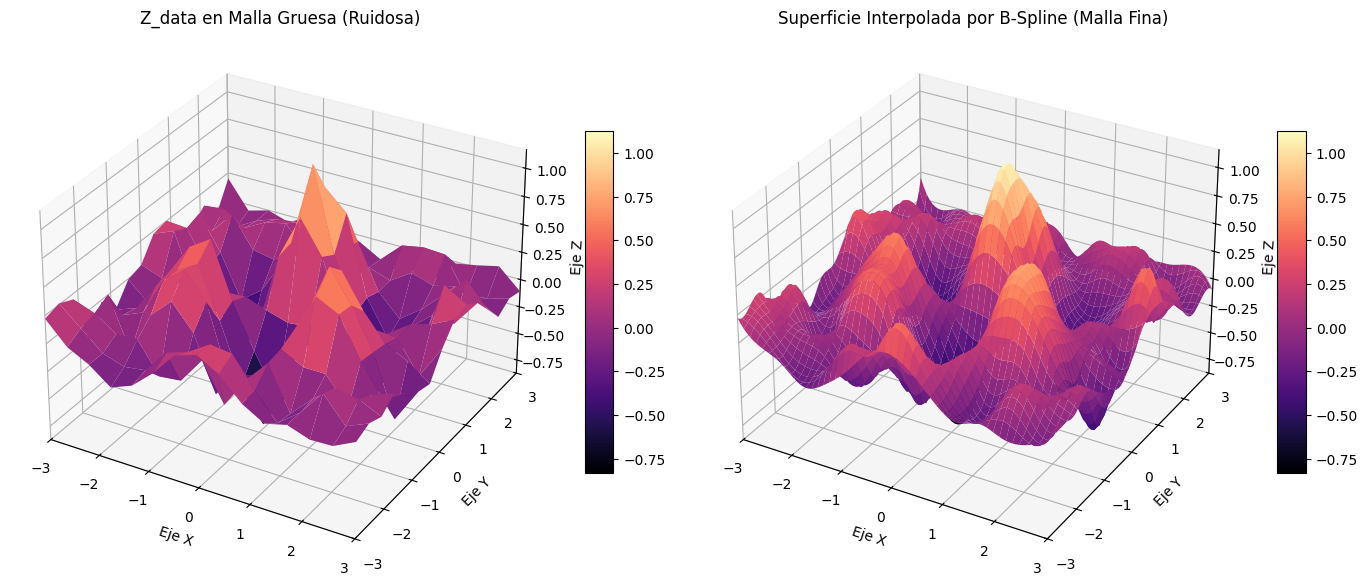

In [4]:
# TODO P2.2: figura comparativa datos vs spline
import matplotlib.pyplot as plt

# Creamos una figura ancha para meter los dos paneles 3D uno al lado del otro
fig = plt.figure(figsize=(14, 6))

# Homogeneizamos la escala de color para ambos gráficos usando el vmin y vmax de Z_data
vmin_val = np.min(Z_data)
vmax_val = np.max(Z_data)
cmap_chosen = 'magma'

# Volvemos a armar la malla gruesa para poder plotear Z_data en 3D
X_raw, Y_raw = np.meshgrid(x_raw, y_raw)

# --- Panel Izquierdo: Datos originales ruidosos ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap=cmap_chosen, vmin=vmin_val, vmax=vmax_val, edgecolor='none')
ax1.set_title("Z_data en Malla Gruesa (Ruidosa)")
ax1.set_xlabel("Eje X")
ax1.set_ylabel("Eje Y")
ax1.set_zlabel("Eje Z")
ax1.set_xlim([-3, 3])
ax1.set_ylim([-3, 3])
fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=12)

# --- Panel Derecho: Superficie suavizada por el Spline ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap=cmap_chosen, vmin=vmin_val, vmax=vmax_val, edgecolor='none')
ax2.set_title("Superficie Interpolada por B-Spline (Malla Fina)")
ax2.set_xlabel("Eje X")
ax2.set_ylabel("Eje Y")
ax2.set_zlabel("Eje Z")
ax2.set_xlim([-3, 3])
ax2.set_ylim([-3, 3])
fig.colorbar(surf2, ax=ax2, shrink=0.6, aspect=12)

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [5]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
import numpy as np

# Aplanamos las mallas gruesas (2D) para trabajar por puntos individuales en el ajuste
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# Armamos la matriz A con las funciones base: columna de unos, columna de X y columna de Y
A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat))

# Resolvemos el sistema sobredeterminado por mínimos cuadrados normales
sol, residuals, rank, s = np.linalg.lstsq(A, z_flat, rcond=None)
c0, c1, c2 = sol

# Mostramos los coeficientes estimados en la pantalla con 4 decimales
print("Coeficientes estimados:")
print(f"c0 (Intercepto) = {c0:.4f}")
print(f"c1 (Pendiente X) = {c1:.4f}")
print(f"c2 (Pendiente Y) = {c2:.4f}")

Coeficientes estimados:
c0 (Intercepto) = 0.0162
c1 (Pendiente X) = -0.0050
c2 (Pendiente Y) = -0.0012


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

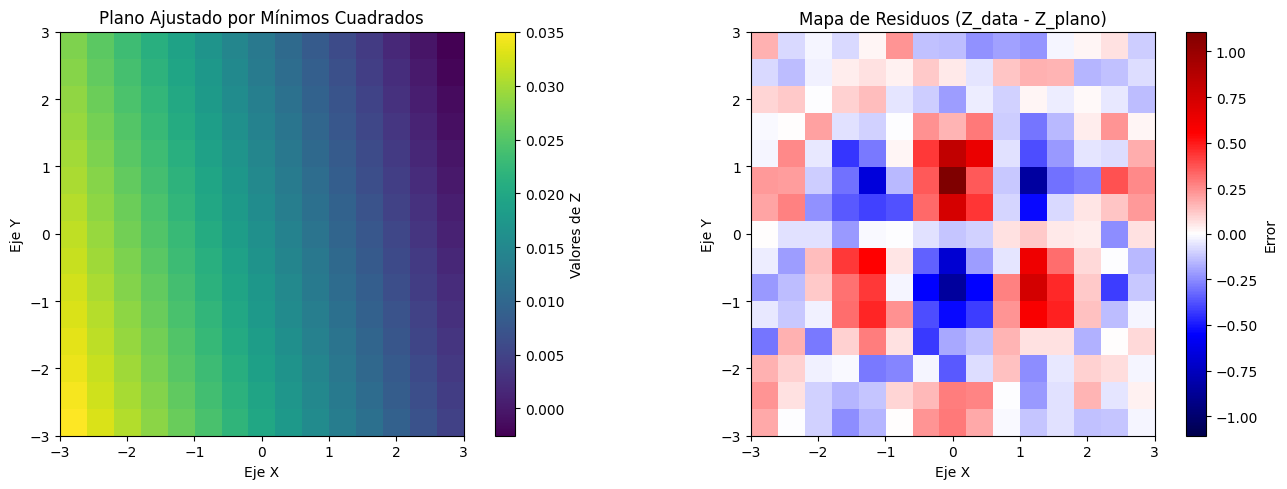

In [6]:
# TODO P3.2: plano ajustado y mapa de residuos
import matplotlib.pyplot as plt

# Evaluamos el plano sobre la malla gruesa original para mantener las dimensiones 2D
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# Calculamos el mapa de residuos como la resta de la matriz ruidosa menos el plano
R = Z_data - Z_plano

# Creamos una figura ancha para meter los dos paneles bidimensionales con imshow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel Izquierdo: Plano Ajustado ---
im1 = ax1.imshow(Z_plano, extent=[-3, 3, -3, 3], origin='lower', cmap='viridis')
ax1.set_title("Plano Ajustado por Mínimos Cuadrados")
ax1.set_xlabel("Eje X")
ax1.set_ylabel("Eje Y")
fig.colorbar(im1, ax=ax1, label="Valores de Z")

# --- Panel Derecho: Mapa de Residuos (Seismic centrado en cero) ---
# Usamos un mapa divergente (seismic) y forzamos vmin/vmax para simetría respecto al 0
max_res = np.max(np.abs(R))
im2 = ax2.imshow(R, extent=[-3, 3, -3, 3], origin='lower', cmap='seismic', vmin=-max_res, vmax=max_res)
ax2.set_title("Mapa de Residuos (Z_data - Z_plano)")
ax2.set_xlabel("Eje X")
ax2.set_ylabel("Eje Y")
fig.colorbar(im2, ax=ax2, label="Error")

plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [7]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=1.60, omega2=2.20


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

In [8]:
import numpy as np
from sklearn.decomposition import PCA

# 1. Centramos los datos restando la media de cada sensor (columna)
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# 2. Inicializamos y ajustamos el modelo PCA para los 3 componentes
pca = PCA(n_components=3)
pca.fit(X_centered)

# 3. Proyectamos los datos originales centrados en el nuevo espacio de componentes principales
X_pca = pca.transform(X_centered)

# 4. Calculamos los porcentajes de varianza explicada
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

# Imprimimos los resultados requeridos en la consola
print("Resultados de PCA:")
for i, var in enumerate(var_explicada):
    print(f"Componente Principal {i+1} (PC{i+1}): {var:.2f}% de varianza explicada.")
print(f"Varianza acumulada por los dos primeros componentes (PC1 + PC2): {var_acumulada[1]:.2f}%")

Resultados de PCA:
Componente Principal 1 (PC1): 48.37% de varianza explicada.
Componente Principal 2 (PC2): 23.39% de varianza explicada.
Componente Principal 3 (PC3): 3.88% de varianza explicada.
Varianza acumulada por los dos primeros componentes (PC1 + PC2): 71.76%


### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

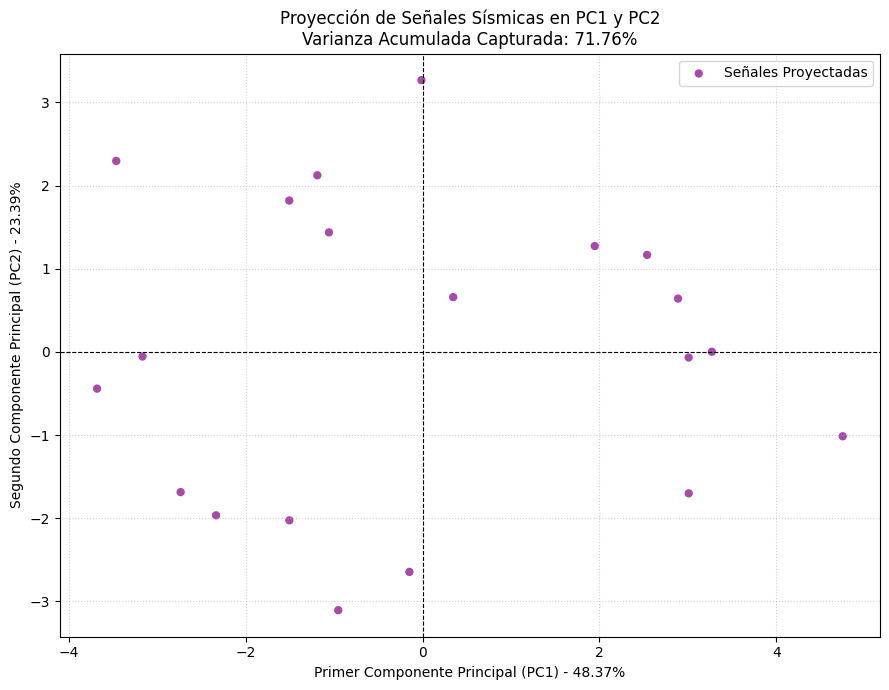

In [9]:
import matplotlib.pyplot as plt

# Creamos la figura para el gráfico de dispersión
plt.figure(figsize=(9, 7))

# Graficamos los puntos proyectados en PC1 (eje X) y PC2 (eje Y)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='purple', alpha=0.7, edgecolors='none', label='Señales Proyectadas')

# Agregamos las líneas de referencia en cero (eje vertical y horizontal) tal como pide la rúbrica
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

# Configuramos etiquetas y activamos la cuadrícula (grid)
plt.xlabel(f"Primer Componente Principal (PC1) - {var_explicada[0]:.2f}%")
plt.ylabel(f"Segundo Componente Principal (PC2) - {var_explicada[1]:.2f}%")
plt.title(f"Proyección de Señales Sísmicas en PC1 y PC2\nVarianza Acumulada Capturada: {var_acumulada[1]:.2f}%")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
